# HP-tuning stability check (step 3, `docs/hp_tuning_design.md`)

Tests whether the *timing* of the HP-tuning block matters. For a subset of stocks,
the same tune → freeze → walk-forward-evaluate pipeline runs **four times**, varying
only where the single 10-day tuning block sits in the sample: at **0%, 25%, 50%, or
75%** of the sample period (5 evenly spaced day-pairs each, same protocol as
`nonlinearity.ipynb` Part 1). Each run evaluates on the days **after** its tuning
block — later tuning means fresher HPs but a shorter eval window; the 0% run is
exactly the design of the full sweep.

Per offset the evaluation fits, per split (train day *i* → test day *i+1*),
**XGBoost** with that offset's frozen per-stock-target winners (incl.
`n_estimators` — no early stopping, no test-day contact). No OLS leg: OLS does
not depend on the tuning block, so its per-day results are offset-invariant and
already exist from the full sweep at 0%.

If all four offsets give the same XGB MSE ratios, the timing of tuning is
irrelevant: tuning once at 0% generalizes and the full search only needs to
happen once. The search is checkpointed per offset × stock, so the notebook can
be interrupted and re-run.

Outputs under `model_outputs/XGBoost/Tuning/stability_seed<SEED>/`:
- `trials_off<pct>/<symbol>.parquet` — random-search trials (checkpoints)
- `best_params_off<pct>.json` — frozen winners per offset
- `daily_diagnostics.parquet` — per stock × day × target × offset_pct

In [7]:
import os, sys, json, warnings
import time
from tqdm.auto import tqdm

import numpy as np
import pandas as pd

from xgboost import XGBRegressor

sys.path.append(os.path.dirname(os.getcwd()))
import importlib
import utils.data_processing as du
import utils.model_utils as mu

importlib.reload(du)
importlib.reload(mu)

<module 'utils.model_utils' from '/home/jovyan/_shared_storage/temp_stud/MA_Otto/utils/model_utils.py'>

In [9]:
# ============================================================
# Configuration — same tuning protocol as nonlinearity.ipynb Part 1;
# the only new axis is OFFSETS (where the tuning block sits).
# ============================================================

STABILITY_SYMBOLS = [
 'Mercedes Benz',
 'Adidas',
 'Zalando',
 'Qiagen',
 'Fresenius Medical Care']

OFFSETS = [0.00, 0.25, 0.50, 0.75]   # tuning-block start as a fraction of the sample

TUNE_BLOCK_LEN = 10                  # trading days per tuning block

N_TRIALS = 40                        # random-search trials per stock-target

N_PAIRS = 5                          # (train, validation) day-pairs per trial

SEED = 0

HORIZONS = ["100ms", "2s", "30s", "5m"]

# Searched hyperparameters: name -> (distribution, low, high)
# "log"/"logint" sample log-uniformly; "int"/"logint" round to integers.
SEARCH_SPACE = {
    "max_depth": ("int", 1, 6),
    "learning_rate": ("log", 0.01, 0.3),
    "min_child_weight": ("logint", 5, 100),
    "subsample": ("uniform", 0.5, 1.0),
    "colsample_bytree": ("uniform", 0.5, 1.0),
    "reg_lambda": ("log", 0.01, 10.0),
}

# Fixed (non-searched) settings for every trial fit; n_estimators is only an
# upper bound — early stopping on the validation day picks the actual tree count.
BASE_PARAMS = dict(
    n_estimators=2000,
    early_stopping_rounds=50,
    eval_metric="rmse",
    tree_method="hist",
    max_bin=128,
    device=mu.select_device(),   # least-used GPU, else "cpu"
    n_jobs=-1,
    random_state=0,
)

# Fixed (non-tuned) settings for the frozen-param evaluation fits.
XGB_PARAMS = dict(
    tree_method="hist",
    max_bin=128,
    device=BASE_PARAMS["device"],
    n_jobs=-1,
    random_state=0,
)
print(f"XGBoost device: {BASE_PARAMS['device']}")

XGBoost device: cuda:0


In [3]:
# ============================================================
# Search functions (copies of nonlinearity.ipynb Part 1)
# ============================================================

def sample_params(rng: np.random.Generator) -> dict:
    """Draw one random-search trial from SEARCH_SPACE."""
    params = {}
    for name, (kind, lo, hi) in SEARCH_SPACE.items():
        if kind == "int":
            params[name] = int(rng.integers(lo, hi + 1))
        elif kind == "uniform":
            params[name] = float(rng.uniform(lo, hi))
        elif kind == "log":
            params[name] = float(np.exp(rng.uniform(np.log(lo), np.log(hi))))
        elif kind == "logint":
            params[name] = int(round(np.exp(rng.uniform(np.log(lo), np.log(hi)))))
        else:
            raise ValueError(f"Unknown distribution kind: {kind}")
    return params


def random_search(
        pairs: list,
        base_params: dict,
        n_trials: int,
        seed: int = 0,
) -> pd.DataFrame:
    """
    Seeded random search for one target (1D y) with day-pair validation.
    Per-pair score = MSE ratio vs. the zero-return benchmark,
    mean(y_val^2) / best_score^2 (scale-invariant); trial score = mean over
    pairs (higher = better). `n_estimators_frozen` = median early-stopped
    best_iteration across the pairs of this config.
    """
    rng = np.random.default_rng(seed)
    rows = []

    for trial in range(n_trials):
        params = sample_params(rng)
        ratios, iterations = [], []

        start = time.perf_counter()
        for X_tr, y_tr, X_val, y_val in pairs:
            model = XGBRegressor(**{**base_params, **params})
            model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
            mse_bench = float(np.mean(y_val ** 2))
            ratios.append(mse_bench / float(model.best_score) ** 2)
            iterations.append(int(model.best_iteration))

        rows.append({
            "trial": trial,
            **params,
            "mean_mse_ratio": float(np.mean(ratios)),
            "n_estimators_frozen": int(np.median(iterations)),
            "fit_seconds": time.perf_counter() - start,
        })

    return pd.DataFrame(rows)


def freeze_winners(all_trials: pd.DataFrame) -> dict:
    """Winning config per stock-target (highest mean_mse_ratio), with
    n_estimators frozen at that config's median stopped-round."""
    best_rows = all_trials.loc[
        all_trials.groupby(["symbol", "target"])["mean_mse_ratio"].idxmax()
    ]
    best_params = {}
    for _, row in best_rows.iterrows():
        params = {
            name: (int(row[name]) if SEARCH_SPACE[name][0] in ("int", "logint") else float(row[name]))
            for name in SEARCH_SPACE
        }
        params["n_estimators"] = max(1, int(row["n_estimators_frozen"]))
        best_params.setdefault(row["symbol"], {})[row["target"]] = params
    return best_params

In [10]:
# ============================================================
# Derived setup: one tuning block + eval window per offset
# ============================================================
warnings.filterwarnings("ignore")

PARENT = os.path.dirname(os.getcwd())
DATA_ROOT = f"{PARENT}/data/processed"
STABILITY_DIR = f"{PARENT}/model_outputs/XGBoost/Tuning/stability_seed{SEED}"

sample_cols = pd.read_parquet(
    f"{DATA_ROOT}/{STABILITY_SYMBOLS[0]}/{du.SAMPLE_DATES[0]}.parquet"
).columns
FEATURE_COLS = list(sample_cols[sample_cols.str.startswith("F_")])
TARGET_COLS = [c for c in sample_cols
               if c.startswith("T_") and c.rsplit("_", 1)[-1] in HORIZONS]

# Per offset: block = TUNE_BLOCK_LEN consecutive days starting at
# round(offset * n_days); eval window = all days strictly after the block.
ALL_DATES = list(du.SAMPLE_DATES)
BLOCKS = {}
for off in OFFSETS:
    start = round(off * len(ALL_DATES))
    tune_dates = ALL_DATES[start:start + TUNE_BLOCK_LEN]
    eval_dates = ALL_DATES[start + TUNE_BLOCK_LEN:]
    if len(tune_dates) < TUNE_BLOCK_LEN or len(eval_dates) < 2:
        raise ValueError(f"offset {off:.0%}: not enough days (tune {len(tune_dates)}, eval {len(eval_dates)})")
    pair_idx = sorted(set(
        np.linspace(0, len(tune_dates) - 2, N_PAIRS).round().astype(int)
    ))
    BLOCKS[off] = {"tune_dates": tune_dates, "eval_dates": eval_dates, "pair_idx": pair_idx}
    print(f"{off:>4.0%}: tune {tune_dates[0]} .. {tune_dates[-1]}, "
          f"eval {eval_dates[0]} .. {eval_dates[-1]} ({len(eval_dates)} days)")

  0%: tune 2023-01-02 .. 2023-01-13, eval 2023-01-16 .. 2023-06-30 (117 days)
 25%: tune 2023-02-15 .. 2023-02-28, eval 2023-03-01 .. 2023-06-30 (85 days)
 50%: tune 2023-03-31 .. 2023-04-17, eval 2023-04-18 .. 2023-06-30 (53 days)
 75%: tune 2023-05-18 .. 2023-05-31, eval 2023-06-01 .. 2023-06-30 (22 days)


In [5]:
# ============================================================
# Main loop: offset -> tune (checkpointed) -> freeze -> evaluate
# Progress is mirrored to STABILITY_DIR/progress.txt so a reconnected
# ssh session can `cat` the current state (tqdm output dies with the
# terminal that started the run).
# ============================================================
GLOBAL_START = time.perf_counter()
daily_results = []

os.makedirs(STABILITY_DIR, exist_ok=True)
progress = mu.Progress(f"{STABILITY_DIR}/progress.txt")

# Load every symbol's full sample once; tune/eval slice the dates they need.
CACHES = {
    symbol: mu.load_day_cache(DATA_ROOT, symbol, ALL_DATES, FEATURE_COLS, TARGET_COLS)
    for symbol in tqdm(STABILITY_SYMBOLS, desc="load", unit="stock")
}

# progress.txt counters: tune counts offset x stock x target units,
# eval counts offset x stock x day-pair units.
N_TUNE_UNITS = len(OFFSETS) * len(STABILITY_SYMBOLS) * len(TARGET_COLS)
N_EVAL_UNITS = sum(
    len(STABILITY_SYMBOLS) * (len(BLOCKS[off]["eval_dates"]) - 1) for off in OFFSETS
)
tune_units_done, eval_units_done = 0, 0
progress.update("tune", 0, N_TUNE_UNITS)
progress.update("eval", 0, N_EVAL_UNITS)

for off in tqdm(OFFSETS, desc="Offsets", unit="offset"):
    off_pct = int(off * 100)
    block = BLOCKS[off]
    tune_dates, eval_dates, pair_idx = block["tune_dates"], block["eval_dates"], block["pair_idx"]
    trials_dir = f"{STABILITY_DIR}/trials_off{off_pct}"

    # ---- Tuning (identical protocol to nonlinearity.ipynb Part 1,
    #      checkpointed per offset x stock)
    for symbol in tqdm(STABILITY_SYMBOLS, desc=f"tune off{off_pct}", leave=False, unit="stock"):
        if os.path.exists(f"{trials_dir}/{symbol}.parquet"):
            tqdm.write(f"off{off_pct} {symbol}: checkpoint found, skipping")
            tune_units_done += len(TARGET_COLS)
            progress.update("tune", tune_units_done, N_TUNE_UNITS)
            continue

        cache = CACHES[symbol]

        symbol_trials = []
        for j, target in enumerate(TARGET_COLS):
            pairs = [
                (cache[tune_dates[i]]["X"], mu.scale_target(cache[tune_dates[i]]["Y"][:, j]),
                 cache[tune_dates[i+1]]["X"], mu.scale_target(cache[tune_dates[i+1]]["Y"][:, j]))
                for i in pair_idx
            ]
            trials = random_search(pairs, base_params=BASE_PARAMS, n_trials=N_TRIALS, seed=SEED)
            trials.insert(0, "target", target)
            trials.insert(0, "symbol", symbol)
            symbol_trials.append(trials)
            tune_units_done += 1
            progress.update("tune", tune_units_done, N_TUNE_UNITS)

        mu.save_table(
            df=pd.concat(symbol_trials, ignore_index=True),
            root_dir=trials_dir,
            filename=f"{symbol}.parquet",
        )

    all_trials = pd.concat(
        [pd.read_parquet(f"{trials_dir}/{symbol}.parquet") for symbol in STABILITY_SYMBOLS],
        ignore_index=True,
    )
    best_params = freeze_winners(all_trials)
    with open(f"{STABILITY_DIR}/best_params_off{off_pct}.json", "w") as f:
        json.dump({"offset": off, "tune_dates": tune_dates, "params": best_params}, f, indent=2)

    # ---- Evaluation on the days after the block: frozen-param XGB
    # (no OLS leg — OLS is offset-invariant; its per-day results come from
    #  the full sweep at 0%)
    for symbol in tqdm(STABILITY_SYMBOLS, desc=f"eval off{off_pct}", leave=False, unit="stock"):
        day_cache = CACHES[symbol]
        symbol_params = best_params[symbol]

        for i in range(len(eval_dates) - 1):
            train_day, test_day = eval_dates[i], eval_dates[i + 1]
            X_train, X_test = day_cache[train_day]["X"], day_cache[test_day]["X"]
            Y_train, Y_test = day_cache[train_day]["Y"], day_cache[test_day]["Y"]

            # XGB, frozen params, no early stopping (targets in scaled units)
            xgb_resid = np.empty_like(Y_test)
            for j, target in enumerate(TARGET_COLS):
                model = XGBRegressor(**{**XGB_PARAMS, **symbol_params[target]})
                model.fit(X_train, mu.scale_target(Y_train[:, j]))
                xgb_resid[:, j] = Y_test[:, j] - mu.unscale_prediction(model.predict(X_test))

            rows = mu.daily_diagnostic_rows(
                resid=xgb_resid,
                Y_test=Y_test,
                target_cols=TARGET_COLS,
                train_day=train_day,
                test_day=test_day,
                symbol=symbol,
                run_id=f"stability_off{off_pct}",
                n_train=X_train.shape[0],
                n_test=X_test.shape[0],
            )
            daily_results += [dict(r, model_leg="xgb", offset_pct=off_pct) for r in rows]
            eval_units_done += 1
            progress.update("eval", eval_units_done, N_EVAL_UNITS)

progress.done("tune")
progress.done("eval")
tqdm.write(f"TOTAL STABILITY-CHECK TIME: {time.perf_counter()-GLOBAL_START:.2f}s")

mu.save_table(
    df=pd.DataFrame(daily_results),
    root_dir=STABILITY_DIR,
    filename="daily_diagnostics.parquet",
)

load:   0%|          | 0/5 [00:00<?, ?stock/s]

Offsets:   0%|          | 0/4 [00:00<?, ?offset/s]

tune off0:   0%|          | 0/5 [00:00<?, ?stock/s]

off0 Mercedes Benz: checkpoint found, skipping
off0 Adidas: checkpoint found, skipping
off0 Zalando: checkpoint found, skipping
off0 Qiagen: checkpoint found, skipping
off0 Fresenius Medical Care: checkpoint found, skipping


eval off0:   0%|          | 0/5 [00:00<?, ?stock/s]

...

eval off50:   0%|          | 0/5 [00:00<?, ?stock/s]

tune off75:   0%|          | 0/5 [00:00<?, ?stock/s]

off75 Mercedes Benz: checkpoint found, skipping


eval off75:   0%|          | 0/5 [00:00<?, ?stock/s]

TOTAL STABILITY-CHECK TIME: 20225.15s


In [27]:
# ============================================================
# Summary: does the tuning-block timing change the conclusion?
# 1) Mean XGB MSE ratio per price measure x horizon x offset
#    (higher = better).
# 2) Same comparison on the SHARED eval window (days after the 75% block,
#    present in every run) so offsets are compared on identical days,
#    not windows of different lengths.
# ============================================================
daily_out = pd.read_parquet(f"{STABILITY_DIR}/daily_diagnostics.parquet")
daily_out["horizon"] = daily_out["target"].str.rsplit("_", n=1).str[-1]
daily_out["horizon"] = pd.Categorical(daily_out["horizon"], categories=HORIZONS, ordered=True)
# target = "T_<measure>_<horizon>", e.g. "T_MidPrice_LogReturn_100ms"
daily_out["measure"] = (daily_out["target"]
                        .str.removeprefix("T_")
                        .str.rsplit("_", n=1).str[0])

display(
    daily_out.pivot_table(index=["measure", "horizon"], columns="offset_pct",
                          values="mse_ratio", observed=True).round(4)
)

shared = daily_out[daily_out["test_day"].isin(BLOCKS[OFFSETS[-1]]["eval_dates"])]
display(
    shared.pivot_table(index=["measure", "horizon"], columns="offset_pct",
                       values="mse_ratio", observed=True).round(4)
)

offset_pct                              0       25      50      75
measure                    horizon                                
MicroPrice_LogReturn       100ms    1.0029  1.0026  1.0020  1.0014
                           2s       0.9995  1.0008  1.0006  1.0004
                           30s      0.9983  0.9982  0.9983  0.9982
                           5m       0.9891  0.9862  0.9858  0.9776
MidPriceCQW_LogReturn      100ms    1.0027  1.0024  1.0018  1.0015
                           2s       0.9999  1.0002  1.0005  1.0004
                           30s      0.9980  0.9985  0.9982  0.9982
                           5m       0.9892  0.9855  0.9850  0.9780
MidPriceQW_LogReturn       100ms    1.0103  1.0090  1.0068  1.0066
                           2s       1.0188  1.0162  1.0126  1.0122
                           30s      0.9982  0.9982  0.9983  0.9961
                           5m       0.9894  0.9880  0.9859  0.9784
MidPrice_LogReturn         100ms    1.0084  1.0076  1.0064  1.0058
                           2s       1.0138  1.0136  1.0133  1.0128
                           30s      0.9983  0.9981  0.9973  0.9983
                           5m       0.9880  0.9863  0.9847  0.9788
TransactionPrice_LogReturn 100ms    1.0016  1.0015  1.0012  1.0011
                           2s       1.0140  1.0136  1.0104  1.0098
                           30s      1.0172  1.0158  1.0124  1.0093
                           5m       0.9857  0.9809  0.9858  0.9735

offset_pct                              0       25      50      75
measure                    horizon                                
MicroPrice_LogReturn       100ms    1.0015  1.0015  1.0016  1.0014
                           2s       0.9992  1.0002  1.0005  1.0004
                           30s      0.9979  0.9981  0.9982  0.9982
                           5m       0.9849  0.9830  0.9845  0.9776
MidPriceCQW_LogReturn      100ms    1.0015  1.0016  1.0017  1.0015
                           2s       0.9994  0.9998  1.0004  1.0004
                           30s      0.9978  0.9984  0.9981  0.9982
                           5m       0.9849  0.9827  0.9838  0.9780
MidPriceQW_LogReturn       100ms    1.0067  1.0066  1.0067  1.0066
                           2s       1.0123  1.0123  1.0126  1.0122
                           30s      0.9978  0.9980  0.9982  0.9961
                           5m       0.9852  0.9848  0.9846  0.9784
MidPrice_LogReturn         100ms    1.0059  1.0058  1.0059  1.0058
                           2s       1.0124  1.0125  1.0129  1.0128
                           30s      0.9979  0.9981  0.9977  0.9983
                           5m       0.9843  0.9832  0.9837  0.9788
TransactionPrice_LogReturn 100ms    1.0011  1.0010  1.0010  1.0011
                           2s       1.0087  1.0092  1.0091  1.0098
                           30s      1.0073  1.0072  1.0088  1.0093
                           5m       0.9809  0.9774  0.9842  0.9735

Dead zones (no offset's XGB nor OLS beats the benchmark):
  MicroPrice_LogReturn @ 30s
  MicroPrice_LogReturn @ 5m
  MidPriceCQW_LogReturn @ 30s
  MidPriceCQW_LogReturn @ 5m
  MidPriceQW_LogReturn @ 30s
  MidPriceQW_LogReturn @ 5m
  MidPrice_LogReturn @ 30s
  MidPrice_LogReturn @ 5m
  TransactionPrice_LogReturn @ 5m

Test days served by each offset in the composite:
offset_pct
0     32
25    32
50    31
75    21
Name: test_day, dtype: int64


,measure,horizon,n_days,mean_diff,se,t,p,ols_win_rate,ratio_ols,ratio_xgb,dead_zone
0,MicroPrice_LogReturn,100ms,116,-0.0003,0.0001,-3.5608,0.0004,0.6983,1.0033,1.0030,False
1,MicroPrice_LogReturn,2s,116,-0.0014,0.0002,-7.2383,0.0000,0.6948,1.0023,1.0009,False
2,MicroPrice_LogReturn,30s,116,0.0118,0.0005,21.8302,0.0000,0.1517,0.9865,0.9983,True
3,MicroPrice_LogReturn,5m,116,0.0229,0.0016,14.2706,0.0000,0.2345,0.9641,0.9870,True
4,MidPriceCQW_LogReturn,100ms,116,-0.0004,0.0001,-4.2306,0.0000,0.6672,1.0031,1.0028,False
5,MidPriceCQW_LogReturn,2s,116,-0.0011,0.0003,-3.9067,0.0001,0.6741,1.0018,1.0007,False
6,MidPriceCQW_LogReturn,30s,116,0.0117,0.0006,20.8467,0.0000,0.1517,0.9866,0.9983,True
7,MidPriceCQW_LogReturn,5m,116,0.0225,0.0016,14.1793,0.0000,0.2345,0.9641,0.9866,True
8,MidPriceQW_LogReturn,100ms,116,-0.0011,0.0001,-7.7443,0.0000,0.8207,1.0114,1.0103,False
9,MidPriceQW_LogReturn,2s,116,-0.0063,0.0003,-21.5123,0.0000,0.9224,1.0251,1.0188,False


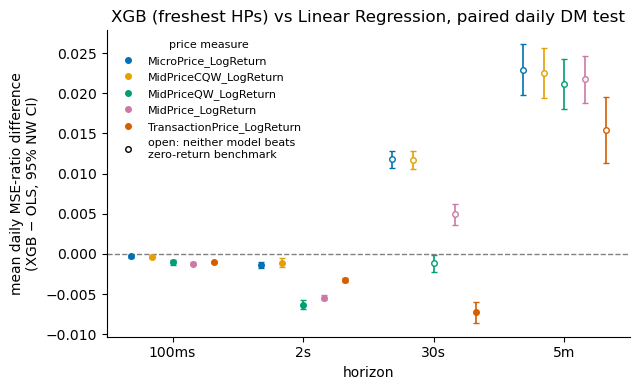

In [32]:
# ============================================================
# Is the XGB improvement over OLS significant? Paired daily DM test.
#
# Headline XGB run = "freshest-HP" COMPOSITE of the four offset runs:
# for each symbol x target x test day, take the row from the HIGHEST
# offset whose eval window contains that day, i.e. always the most
# recently tuned hyperparameters. Days inside offset k's tuning block
# lie in earlier offsets' eval windows (not in offset k's), so they
# automatically fall back to the previous offset's HPs — nothing is
# omitted, and every day's HPs come from strictly earlier days
# (no leakage). Coverage = all days after the 0% block.
#
# Dead zones, offset-independently: on the test days shared by ALL
# offsets, a measure x horizon cell is a DEAD ZONE if neither OLS nor
# ANY offset's XGB run beats the zero-return benchmark (all mean MSE
# ratios <= 1). There a positive XGB-vs-OLS differential only says XGB
# is less bad at an unpredictable target (hugging the no-change
# benchmark harder), not that it found signal.
#
# DM test: paired vs. the Linear Regression run on the shared
# symbol x test_day x target observations,
#     d_t = mse_ratio_XGB - mse_ratio_OLS   (positive = XGB better),
# averaged across stocks per day (clustering by day: stock-days are not
# cross-sectionally independent), then a Diebold-Mariano-style t-test
# with Newey-West standard errors on the daily cross-stock mean series.
#
# Output: one dot-and-CI figure — mean daily differential with 95% CI
# per price measure x horizon; open markers = dead zone. CIs
# straddling/below zero = no significant XGB advantage.
# ============================================================

DM_REGRESSION_RUN_ID = "05"   # run under model_outputs/Regression/runs/
DM_XGB_LABEL = "freshest HPs"

ols_daily = pd.read_parquet(
    f"{PARENT}/model_outputs/Regression/runs/{DM_REGRESSION_RUN_ID}/daily_diagnostics.parquet"
)

# ---- Dead zones on the days shared by ALL offsets
_shared_all = set.intersection(*(
    set(daily_out.loc[daily_out["offset_pct"] == p, "test_day"])
    for p in daily_out["offset_pct"].unique()
))
# left has one row per offset per symbol x test_day x target -> many_to_one
paired_all = daily_out[daily_out["test_day"].isin(_shared_all)].merge(
    ols_daily[["symbol", "test_day", "target", "mse_ratio"]],
    on=["symbol", "test_day", "target"],
    suffixes=("_xgb", "_ols"),
    validate="many_to_one",
)
cell_means = (paired_all.groupby(["measure", "horizon", "offset_pct"], observed=True)
              [["mse_ratio_xgb", "mse_ratio_ols"]].mean())
DEAD_ZONES = set(
    cell_means.groupby(["measure", "horizon"], observed=True)
    .agg({"mse_ratio_xgb": "max", "mse_ratio_ols": "first"})
    .query("mse_ratio_xgb <= 1 and mse_ratio_ols <= 1").index
)
print("Dead zones (no offset's XGB nor OLS beats the benchmark):")
for mz in sorted(DEAD_ZONES):
    print(f"  {mz[0]} @ {mz[1]}")

# ---- Freshest-HP composite: per symbol x target x test day, the row
#      with the highest offset (= most recently tuned HPs)
xgb_leg = daily_out.loc[
    daily_out.groupby(["symbol", "target", "test_day"])["offset_pct"].idxmax()
]
print("\nTest days served by each offset in the composite:")
print(xgb_leg.groupby("offset_pct")["test_day"].nunique())


def newey_west_tstat(d: np.ndarray) -> tuple:
    """Mean, NW standard error, t-stat, and two-sided p-value of a series
    (HAC lag = floor(1.5 * T^(1/3)), Bartlett kernel, normal p-value)."""
    from scipy import stats
    T = len(d)
    mean = d.mean()
    u = d - mean
    lag = int(np.floor(1.5 * T ** (1 / 3)))
    s = float(u @ u) / T
    for k in range(1, lag + 1):
        s += 2 * (1 - k / (lag + 1)) * float(u[k:] @ u[:-k]) / T
    se = np.sqrt(s / T)
    t = mean / se
    return mean, se, t, 2 * stats.norm.sf(abs(t))


# ---- Paired daily DM test for the composite
paired = xgb_leg.merge(
    ols_daily[["symbol", "test_day", "target", "mse_ratio"]],
    on=["symbol", "test_day", "target"],
    suffixes=("_xgb", "_ols"),
    validate="one_to_one",
)
paired["d"] = paired["mse_ratio_xgb"] - paired["mse_ratio_ols"]

# Daily cross-stock mean differential, then NW t-test per measure x horizon
by_day = (paired.groupby(["measure", "horizon", "test_day"], observed=True)["d"]
                .mean().reset_index())

dm_rows = []
for (measure, horizon), g in by_day.groupby(["measure", "horizon"], observed=True):
    d = g.sort_values("test_day")["d"].to_numpy()
    mean, se, t, p = newey_west_tstat(d)
    cell = paired[(paired["measure"] == measure) & (paired["horizon"] == horizon)]
    dm_rows.append({"measure": measure, "horizon": horizon, "n_days": len(d),
                    "mean_diff": mean, "se": se, "t": t, "p": p,
                    "ols_win_rate": float((cell["d"] <= 0).mean()),
                    "ratio_ols": float(cell["mse_ratio_ols"].mean()),
                    "ratio_xgb": float(cell["mse_ratio_xgb"].mean()),
                    "dead_zone": (measure, horizon) in DEAD_ZONES})
dm = pd.DataFrame(dm_rows)
dm["horizon"] = pd.Categorical(dm["horizon"], categories=HORIZONS, ordered=True)
display(dm.sort_values(["measure", "horizon"]).round(4))

# ---- Dot-and-CI figure; open markers = dead zone (neither model beats
#      the zero-return benchmark)
fig, ax = plt.subplots(figsize=(6.5, 4))
x = np.arange(len(HORIZONS))
measures = sorted(dm["measure"].unique())
width = 0.8 / len(measures)
for k, measure in enumerate(measures):
    g = dm[dm["measure"] == measure].set_index("horizon").reindex(HORIZONS)
    xs = x + (k - (len(measures) - 1) / 2) * width
    for xi, (_, row) in zip(xs, g.iterrows()):
        color = MEASURE_COLORS.get(measure)
        ax.errorbar(xi, row["mean_diff"], yerr=1.96 * row["se"], fmt="o", ms=4,
                    lw=1.2, capsize=2, color=color,
                    markerfacecolor="white" if row["dead_zone"] else color)
    ax.plot([], [], "o", ms=4, color=MEASURE_COLORS.get(measure), label=measure)
ax.axhline(0.0, color="gray", lw=1, ls="--")
ax.set_xticks(x)
ax.set_xticklabels(HORIZONS)
ax.set_xlabel("horizon")
ax.set_ylabel("mean daily MSE-ratio difference\n(XGB − OLS, 95% NW CI)")
ax.set_title(f"XGB ({DM_XGB_LABEL}) vs Linear Regression, paired daily DM test")
ax.spines[["top", "right"]].set_visible(False)
handles, labels = ax.get_legend_handles_labels()
handles.append(Line2D([], [], marker="o", ls="", ms=4, color="black",
                      markerfacecolor="white",
                      label="open: neither model beats\nzero-return benchmark"))
ax.legend(handles=handles, title="price measure", frameon=False,
          fontsize=8, title_fontsize=8)
fig.tight_layout()

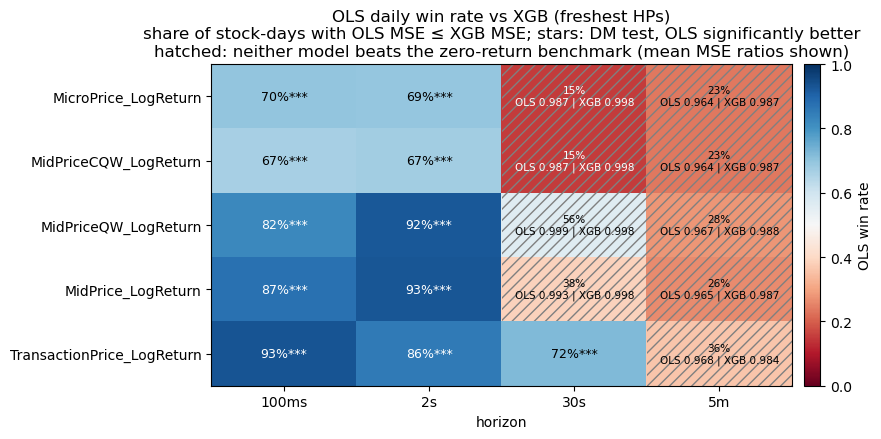

In [33]:
# ============================================================
# Companion heatmap: OLS daily win rate per measure x horizon.
# Cell value = fraction of paired stock-days where OLS matches or
# beats XGB (d <= 0); annotation adds significance stars from the
# DM test above (on the daily cross-stock mean differential):
# * p<0.05, ** p<0.01, *** p<0.001 — stars mark cells where the
# mean differential is significantly NEGATIVE (OLS better).
# Dead-zone cells (neither model beats the zero-return benchmark)
# are hatched and annotated with the mean MSE-ratio levels instead
# of stars: there the comparison is between two losing models, so
# "XGB wins" only means hugging the no-change benchmark harder.
# Uses `dm` from the previous cell.
# ============================================================

heat = (dm.pivot(index="measure", columns="horizon", values="ols_win_rate")
          .reindex(columns=HORIZONS).sort_index())
pvals = dm.pivot(index="measure", columns="horizon", values="p").reindex(
    index=heat.index, columns=HORIZONS)
means = dm.pivot(index="measure", columns="horizon", values="mean_diff").reindex(
    index=heat.index, columns=HORIZONS)
dead = dm.pivot(index="measure", columns="horizon", values="dead_zone").reindex(
    index=heat.index, columns=HORIZONS)
r_ols = dm.pivot(index="measure", columns="horizon", values="ratio_ols").reindex(
    index=heat.index, columns=HORIZONS)
r_xgb = dm.pivot(index="measure", columns="horizon", values="ratio_xgb").reindex(
    index=heat.index, columns=HORIZONS)


def stars(p, mean_diff):
    if mean_diff >= 0:
        return ""
    return "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""


fig, ax = plt.subplots(figsize=(1.6 * len(HORIZONS) + 2.5, 0.6 * len(heat) + 1.5))
im = ax.imshow(heat.to_numpy(), cmap="RdBu", vmin=0.0, vmax=1.0, aspect="auto")
for r in range(heat.shape[0]):
    for c in range(heat.shape[1]):
        v = heat.iat[r, c]
        txt_color = "white" if abs(v - 0.5) > 0.3 else "black"
        if dead.iat[r, c]:
            ax.add_patch(plt.Rectangle((c - 0.5, r - 0.5), 1, 1, fill=False,
                                       hatch="///", edgecolor="gray", lw=0))
            ax.text(c, r, f"{v:.0%}\nOLS {r_ols.iat[r, c]:.3f} | XGB {r_xgb.iat[r, c]:.3f}",
                    ha="center", va="center", fontsize=7.5, color=txt_color)
        else:
            ax.text(c, r, f"{v:.0%}{stars(pvals.iat[r, c], means.iat[r, c])}",
                    ha="center", va="center", fontsize=9, color=txt_color)
ax.set_xticks(range(len(HORIZONS)))
ax.set_xticklabels(HORIZONS)
ax.set_yticks(range(len(heat)))
ax.set_yticklabels(heat.index)
ax.set_xlabel("horizon")
ax.set_title(f"OLS daily win rate vs XGB ({DM_XGB_LABEL})\n"
             "share of stock-days with OLS MSE ≤ XGB MSE; stars: DM test, OLS "
             "significantly better\nhatched: neither model beats the zero-return "
             "benchmark (mean MSE ratios shown)")
fig.colorbar(im, ax=ax, label="OLS win rate", fraction=0.04, pad=0.02)
fig.tight_layout()

,measure,horizon,n_days,mean_diff,se,t,p,fresh_win_rate,dead_zone
0,MicroPrice_LogReturn,100ms,84,0.0000,0.0000,1.8655,0.0621,0.5095,False
1,MicroPrice_LogReturn,2s,84,0.0019,0.0003,6.4540,0.0000,0.5833,False
2,MicroPrice_LogReturn,30s,84,0.0000,0.0001,0.2455,0.8061,0.5405,True
3,MicroPrice_LogReturn,5m,84,-0.0030,0.0008,-3.5313,0.0004,0.4238,True
4,MidPriceCQW_LogReturn,100ms,84,0.0001,0.0000,2.2026,0.0276,0.5857,False
5,MidPriceCQW_LogReturn,2s,84,0.0012,0.0002,6.0710,0.0000,0.6667,False
6,MidPriceCQW_LogReturn,30s,84,0.0004,0.0001,2.8184,0.0048,0.5667,True
7,MidPriceCQW_LogReturn,5m,84,-0.0035,0.0008,-4.5846,0.0000,0.4000,True
8,MidPriceQW_LogReturn,100ms,84,0.0000,0.0000,0.5066,0.6124,0.5167,False
9,MidPriceQW_LogReturn,2s,84,0.0000,0.0001,0.0607,0.9516,0.4381,False


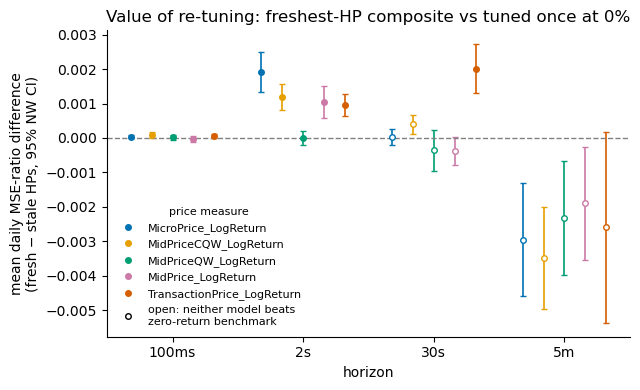

In [34]:
# ============================================================
# Within-XGB: is re-tuning worth anything? Paired daily DM test of the
# freshest-HP composite vs. the 0%-tuned run (tune-once design of the
# full sweep). Restricted to the test days where the two actually
# differ (composite uses an offset > 0%); on earlier days they are
# identical and would only dilute the differential with zeros.
#     d_t = mse_ratio_fresh - mse_ratio_stale   (positive = re-tuning helps)
# Same aggregation and NW t-test as the OLS comparison. If nothing is
# significant, tuning once at the start of the sample is justified.
# Uses `xgb_leg` (composite) and `newey_west_tstat` from the DM cell.
# ============================================================

fresh_days = set(xgb_leg.loc[xgb_leg["offset_pct"] > 0, "test_day"])
stale = daily_out[(daily_out["offset_pct"] == 0)
                  & daily_out["test_day"].isin(fresh_days)]

paired_x = xgb_leg[xgb_leg["test_day"].isin(fresh_days)].merge(
    stale[["symbol", "test_day", "target", "mse_ratio"]],
    on=["symbol", "test_day", "target"],
    suffixes=("_fresh", "_stale"),
    validate="one_to_one",
)
paired_x["d"] = paired_x["mse_ratio_fresh"] - paired_x["mse_ratio_stale"]

by_day_x = (paired_x.groupby(["measure", "horizon", "test_day"], observed=True)["d"]
                    .mean().reset_index())

rt_rows = []
for (measure, horizon), g in by_day_x.groupby(["measure", "horizon"], observed=True):
    d = g.sort_values("test_day")["d"].to_numpy()
    mean, se, t, p = newey_west_tstat(d)
    cell = paired_x[(paired_x["measure"] == measure) & (paired_x["horizon"] == horizon)]
    rt_rows.append({"measure": measure, "horizon": horizon, "n_days": len(d),
                    "mean_diff": mean, "se": se, "t": t, "p": p,
                    "fresh_win_rate": float((cell["d"] > 0).mean()),
                    "dead_zone": (measure, horizon) in DEAD_ZONES})
retune = pd.DataFrame(rt_rows)
retune["horizon"] = pd.Categorical(retune["horizon"], categories=HORIZONS, ordered=True)
display(retune.sort_values(["measure", "horizon"]).round(4))

fig, ax = plt.subplots(figsize=(6.5, 4))
x = np.arange(len(HORIZONS))
width = 0.8 / len(measures)
for k, measure in enumerate(measures):
    g = retune[retune["measure"] == measure].set_index("horizon").reindex(HORIZONS)
    xs = x + (k - (len(measures) - 1) / 2) * width
    for xi, (_, row) in zip(xs, g.iterrows()):
        color = MEASURE_COLORS.get(measure)
        ax.errorbar(xi, row["mean_diff"], yerr=1.96 * row["se"], fmt="o", ms=4,
                    lw=1.2, capsize=2, color=color,
                    markerfacecolor="white" if row["dead_zone"] else color)
    ax.plot([], [], "o", ms=4, color=MEASURE_COLORS.get(measure), label=measure)
ax.axhline(0.0, color="gray", lw=1, ls="--")
ax.set_xticks(x)
ax.set_xticklabels(HORIZONS)
ax.set_xlabel("horizon")
ax.set_ylabel("mean daily MSE-ratio difference\n(fresh − stale HPs, 95% NW CI)")
ax.set_title("Value of re-tuning: freshest-HP composite vs tuned once at 0%")
ax.spines[["top", "right"]].set_visible(False)
handles, _ = ax.get_legend_handles_labels()
handles.append(Line2D([], [], marker="o", ls="", ms=4, color="black",
                      markerfacecolor="white",
                      label="open: neither model beats\nzero-return benchmark"))
ax.legend(handles=handles, title="price measure", frameon=False,
          fontsize=8, title_fontsize=8)
fig.tight_layout()

,best,median,best_minus_median,best_minus_q25
horizon,,,,
100ms,1.0050,1.0045,0.0006,0.0010
2s,1.0107,1.0088,0.0019,0.0029
30s,1.0059,1.0039,0.0020,0.0030
5m,0.9929,0.9897,0.0031,0.0048


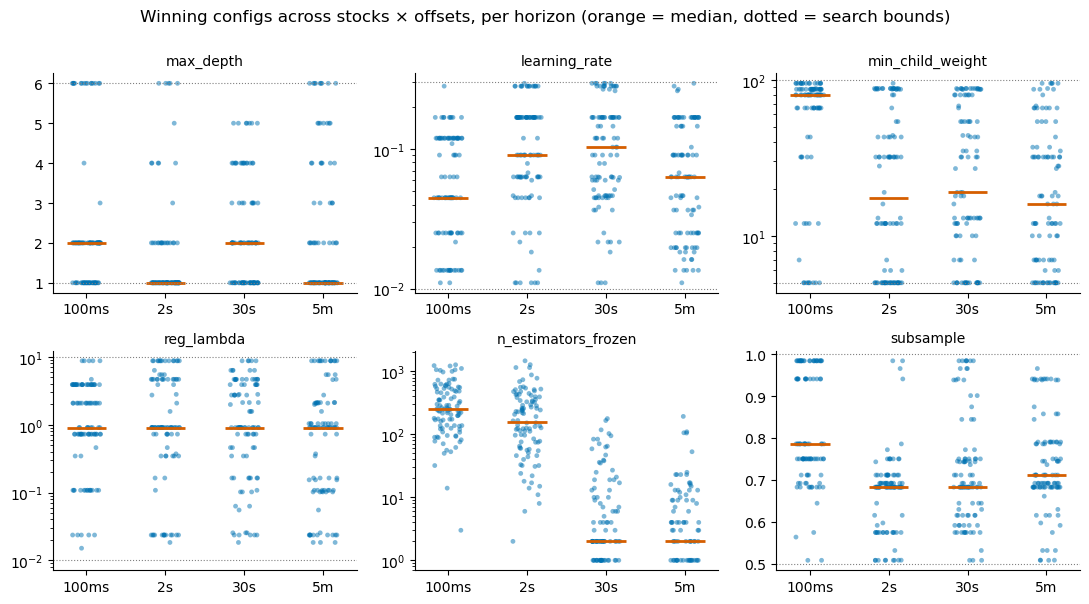

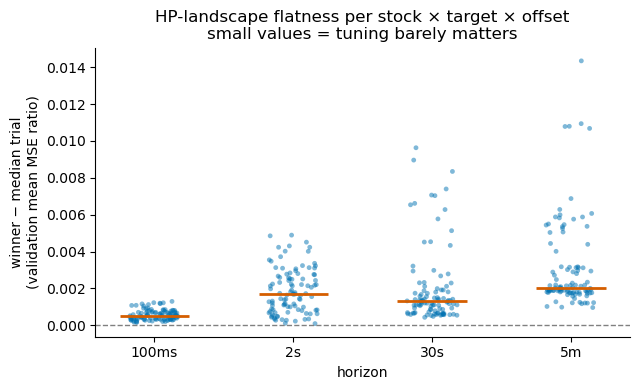

In [35]:
# ============================================================
# What does the tuner actually choose?
# (a) Chosen complexity vs horizon: distribution of the WINNING config's
#     hyperparameters (plus frozen n_estimators) across stocks x offsets,
#     per horizon. If short horizons systematically get shallow, heavily
#     regularized, near-additive models, the tuned XGB is choosing to be
#     ~linear exactly where predictability exists — a structural
#     explanation for the OLS result.
# (b) HP-landscape flatness: per stock x target x offset, the spread of
#     mean_mse_ratio across the 40 random-search trials (winner vs
#     median vs 25th percentile), aggregated per horizon. A flat
#     landscape means tuning barely matters, which explains both the
#     offset stability and any winner drift.
# Reads the trials parquets already on disk; no model fits.
# ============================================================

trials_all = pd.concat(
    [pd.read_parquet(f"{STABILITY_DIR}/trials_off{int(off * 100)}/{symbol}.parquet")
     .assign(offset_pct=int(off * 100))
     for off in OFFSETS for symbol in STABILITY_SYMBOLS],
    ignore_index=True,
)
trials_all["horizon"] = pd.Categorical(
    trials_all["target"].str.rsplit("_", n=1).str[-1], categories=HORIZONS, ordered=True)

winners = trials_all.loc[
    trials_all.groupby(["offset_pct", "symbol", "target"])["mean_mse_ratio"].idxmax()
].copy()

# ---- (a) winning-config parameters by horizon
COMPLEXITY_PARAMS = ["max_depth", "learning_rate", "min_child_weight",
                     "reg_lambda", "n_estimators_frozen", "subsample"]
LOG_SCALE = {"learning_rate", "min_child_weight", "reg_lambda", "n_estimators_frozen"}

fig, axes = plt.subplots(2, 3, figsize=(11, 6))
rng = np.random.default_rng(0)   # jitter only
for ax, param in zip(axes.flat, COMPLEXITY_PARAMS):
    for h, horizon in enumerate(HORIZONS):
        vals = winners.loc[winners["horizon"] == horizon, param].to_numpy(dtype=float)
        ax.scatter(h + rng.uniform(-0.18, 0.18, len(vals)), vals,
                   s=12, alpha=0.5, color="#0072B2", edgecolors="none")
        ax.hlines(np.median(vals), h - 0.25, h + 0.25, color="#D55E00", lw=2)
    if param in LOG_SCALE:
        ax.set_yscale("log")
    lo, hi = SEARCH_SPACE.get(param, (None, None, None))[1:] if param in SEARCH_SPACE else (None, None)
    if lo is not None:
        ax.axhline(lo, color="gray", lw=0.8, ls=":")
        ax.axhline(hi, color="gray", lw=0.8, ls=":")
    ax.set_xticks(range(len(HORIZONS)))
    ax.set_xticklabels(HORIZONS)
    ax.set_title(param, fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("Winning configs across stocks × offsets, per horizon "
             "(orange = median, dotted = search bounds)", y=1.0)
fig.tight_layout()

# ---- (b) landscape flatness: trial-score quantiles vs winner
flat = (trials_all.groupby(["offset_pct", "symbol", "target", "horizon"], observed=True)
        ["mean_mse_ratio"]
        .agg(best="max", median="median", q25=lambda s: s.quantile(0.25))
        .reset_index())
flat["best_minus_median"] = flat["best"] - flat["median"]
flat["best_minus_q25"] = flat["best"] - flat["q25"]

display(flat.groupby("horizon", observed=True)
        [["best", "median", "best_minus_median", "best_minus_q25"]]
        .mean().round(4))

fig, ax = plt.subplots(figsize=(6.5, 4))
for h, horizon in enumerate(HORIZONS):
    vals = flat.loc[flat["horizon"] == horizon, "best_minus_median"].to_numpy()
    ax.scatter(h + rng.uniform(-0.18, 0.18, len(vals)), vals,
               s=12, alpha=0.5, color="#0072B2", edgecolors="none")
    ax.hlines(np.median(vals), h - 0.25, h + 0.25, color="#D55E00", lw=2)
ax.axhline(0.0, color="gray", lw=1, ls="--")
ax.set_xticks(range(len(HORIZONS)))
ax.set_xticklabels(HORIZONS)
ax.set_xlabel("horizon")
ax.set_ylabel("winner − median trial\n(validation mean MSE ratio)")
ax.set_title("HP-landscape flatness per stock × target × offset\n"
             "small values = tuning barely matters")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()